<h1 style="color:white; background-color:blue; padding:20px; border-radius:20px; text-align:center;">
Filtre de Hanning & Loi Normale Asymétrique (Skew-Normal)
</h1>

<h2 style="color:white; background-color:blue; padding:20px; border-radius:20px; text-align:center;">
Analyse des 10 sociétés du Secteur Aéronautique (Aerospace)
</h2>

# Company Analysis: AIR.PA, AM.PA


### 0. Imports

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm
from scipy.optimize import minimize

### 1. Load Data

In [3]:
START_DATE = "2023-01-04"
DATA_DIR   = "../../data/Secteur_Aerospace"
OUTPUT_DIR = "../json"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

airpa_df = pd.read_csv(f"{DATA_DIR}/AIR.PA.csv")
airpa_df = airpa_df[["Date", "Adj Close"]].copy()
airpa_df.columns = ["Date", "X_t"]

ampa_df = pd.read_csv(f"{DATA_DIR}/AM.PA.csv")
ampa_df = ampa_df[["Date", "Adj Close"]].copy()
ampa_df.columns = ["Date", "X_t"]

### 2. Clean Data

In [4]:
airpa_df["Date"] = pd.to_datetime(airpa_df["Date"])
airpa_df = airpa_df[airpa_df["Date"] >= pd.Timestamp(START_DATE)].copy()
airpa_df = airpa_df.sort_values("Date").dropna().reset_index(drop=True)

ampa_df["Date"] = pd.to_datetime(ampa_df["Date"])
ampa_df = ampa_df[ampa_df["Date"] >= pd.Timestamp(START_DATE)].copy()
ampa_df = ampa_df.sort_values("Date").dropna().reset_index(drop=True)

print("AIR.PA shape:", airpa_df.shape)
print("AM.PA  shape:", ampa_df.shape)

AIR.PA shape: (785, 2)
AM.PA  shape: (785, 2)


### 3. Hanning Filter
$$Y_t = \frac{1}{4}X_{t-1} + \frac{1}{2}X_t + \frac{1}{4}X_{t+1}$$

In [5]:
airpa_df["Y_t"] = (
    0.25 * airpa_df["X_t"].shift(1) +
    0.50 * airpa_df["X_t"] +
    0.25 * airpa_df["X_t"].shift(-1)
)
airpa_df = airpa_df.dropna().reset_index(drop=True)

ampa_df["Y_t"] = (
    0.25 * ampa_df["X_t"].shift(1) +
    0.50 * ampa_df["X_t"] +
    0.25 * ampa_df["X_t"].shift(-1)
)
ampa_df = ampa_df.dropna().reset_index(drop=True)

**Plot Raw Series vs Hanning Filtered — AIR.PA**

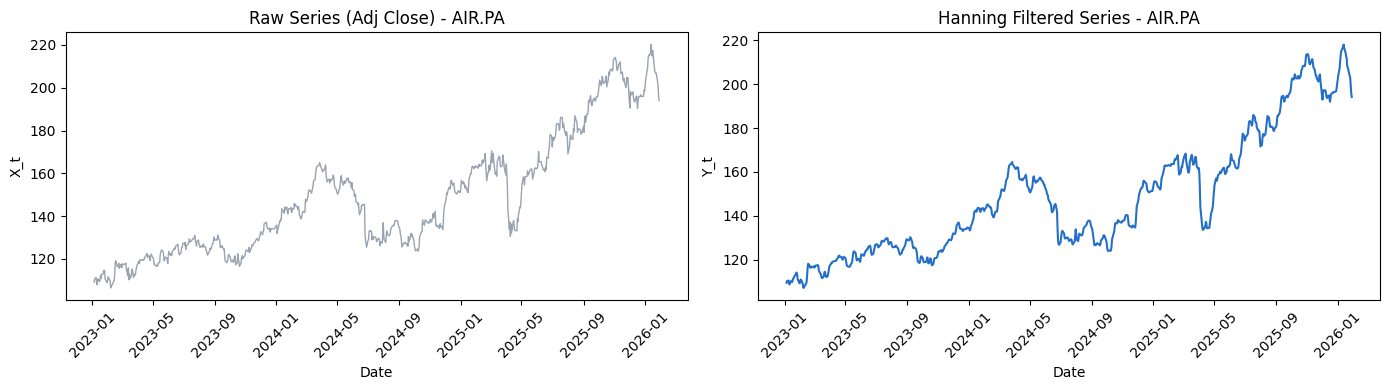

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(airpa_df["Date"], airpa_df["X_t"], color='#9AA3B0', lw=1)
axes[0].set_title("Raw Series (Adj Close) - AIR.PA")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("X_t")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(airpa_df["Date"], airpa_df["Y_t"], color='#2470C8', lw=1.5)
axes[1].set_title("Hanning Filtered Series - AIR.PA")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Y_t")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Plot Raw Series vs Hanning Filtered — AM.PA**

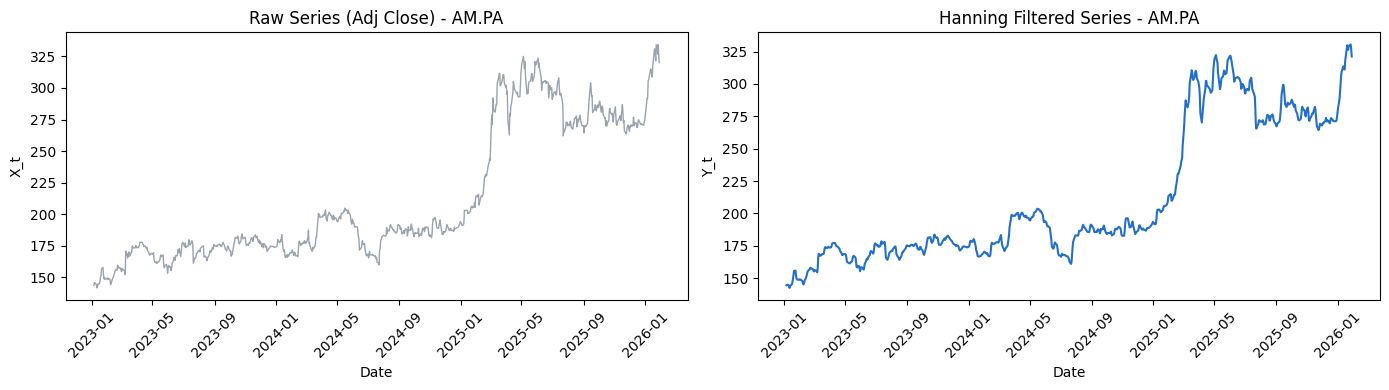

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ampa_df["Date"], ampa_df["X_t"], color='#9AA3B0', lw=1)
axes[0].set_title("Raw Series (Adj Close) - AM.PA")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("X_t")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(ampa_df["Date"], ampa_df["Y_t"], color='#2470C8', lw=1.5)
axes[1].set_title("Hanning Filtered Series - AM.PA")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Y_t")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### 4. Define Skew-Normal PDF and MLE functions

In [8]:
def skew_normal_pdf(x, mu, sigma, theta):
    z = (x - mu) / sigma
    return (2.0 / sigma) * norm.pdf(z) * norm.cdf(theta * z)


def neg_loglik_common_theta(params, y_left, y_right):
    """
    params = [mu1, log_sigma1, mu2, log_sigma2, theta]
    Common theta across both segments, as required by Sujet 3.
    """
    mu1, log_sigma1, mu2, log_sigma2, theta = params
    sigma1 = np.exp(log_sigma1)
    sigma2 = np.exp(log_sigma2)

    if sigma1 <= 0 or sigma2 <= 0 or not np.isfinite(theta):
        return np.inf

    pdf1 = np.clip(skew_normal_pdf(y_left,  mu1, sigma1, theta), 1e-12, None)
    pdf2 = np.clip(skew_normal_pdf(y_right, mu2, sigma2, theta), 1e-12, None)

    return -(np.sum(np.log(pdf1)) + np.sum(np.log(pdf2)))


def fit_sn_two_regimes(Y, k):
    """Fit SN MLE on both segments with common theta."""
    y1 = Y[:k]
    y2 = Y[k:]

    mu1_init    = float(np.mean(y1))
    mu2_init    = float(np.mean(y2))
    sigma1_init = max(float(np.std(y1, ddof=0)), 1e-3)
    sigma2_init = max(float(np.std(y2, ddof=0)), 1e-3)

    x0 = np.array([mu1_init, np.log(sigma1_init),
                   mu2_init, np.log(sigma2_init), 0.0])

    result = minimize(
        neg_loglik_common_theta,
        x0=x0, args=(y1, y2), method="L-BFGS-B"
    )
    if not result.success:
        print("Warning: optimization did not fully converge.")
        print("Message:", result.message)

    mu1_hat, ls1, mu2_hat, ls2, theta_hat = result.x
    return {
        "mu1"   : float(mu1_hat),
        "sigma1": float(np.exp(ls1)),
        "mu2"   : float(mu2_hat),
        "sigma2": float(np.exp(ls2)),
        "theta" : float(theta_hat),
        "n1"    : len(y1),
        "n2"    : len(y2),
        "negll" : float(result.fun),
    }

---
## AIR.PA

### 5. KS Scan over k — AIR.PA

In [9]:
Y = airpa_df["Y_t"].to_numpy()
n = len(Y)

k_values, ks_stats, p_values = [], [], []

for k in range(30, n - 29):
    stat, pval = ks_2samp(Y[:k], Y[k:])
    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat      = k_values[best_index]
best_ks    = float(ks_stats[best_index])
best_pval  = float(p_values[best_index])
break_date = airpa_df.loc[k_hat, "Date"]

print("Best rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)

Best rupture point from KS scan
k_hat      = 628
break_date = 2025-06-24
KS stat    = 1.0
p-value    = 3.5664768649755256e-168


**KS Scan Plot — AIR.PA**

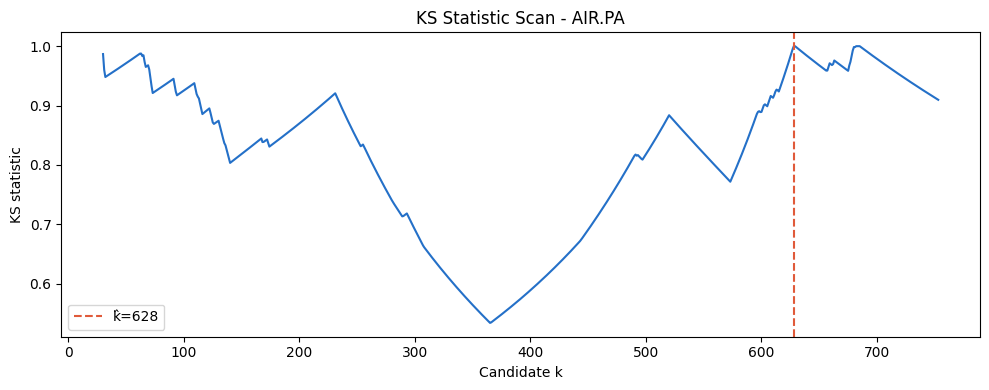

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(k_values, ks_stats, color='#2470C8', lw=1.5)
plt.axvline(k_hat, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
plt.title("KS Statistic Scan - AIR.PA")
plt.xlabel("Candidate k"); plt.ylabel("KS statistic")
plt.legend(); plt.tight_layout(); plt.show()

**Breakpoint Detection Plot — AIR.PA**

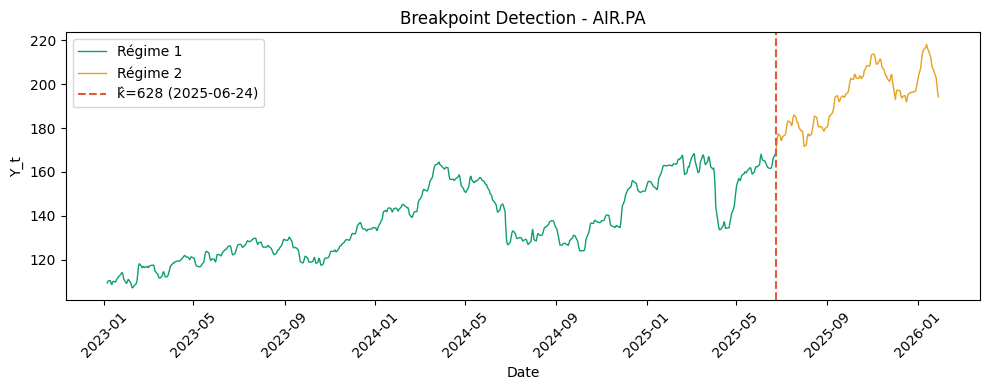

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(airpa_df["Date"][:k_hat], Y[:k_hat], color='#0E9E74', lw=1, label='Régime 1')
plt.plot(airpa_df["Date"][k_hat:], Y[k_hat:], color='#E8A020', lw=1, label='Régime 2')
plt.axvline(break_date, color='#E05A3A', linestyle='--', label=f'k̂={k_hat} ({break_date.date()})')
plt.title("Breakpoint Detection - AIR.PA")
plt.xlabel("Date"); plt.ylabel("Y_t")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

### 6. Estimate Skew-Normal Parameters — AIR.PA

In [12]:
sn_airpa = fit_sn_two_regimes(Y, k_hat)

mu1_hat    = sn_airpa['mu1']
sigma1_hat = sn_airpa['sigma1']
mu2_hat    = sn_airpa['mu2']
sigma2_hat = sn_airpa['sigma2']
theta_hat  = sn_airpa['theta']

print("Joint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", sn_airpa['negll'])

Joint MLE estimates with common theta
mu1    = 137.11864084394904
sigma1 = 16.525943790695116
mu2    = 194.33
sigma2 = 12.578285561287371
theta  = 0.0
NegLogLik = 3264.9815052806853


In [13]:
verdict_airpa = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"
print("Verdict:", verdict_airpa)

Verdict: Reject H0


**SN Density Fit — AIR.PA**

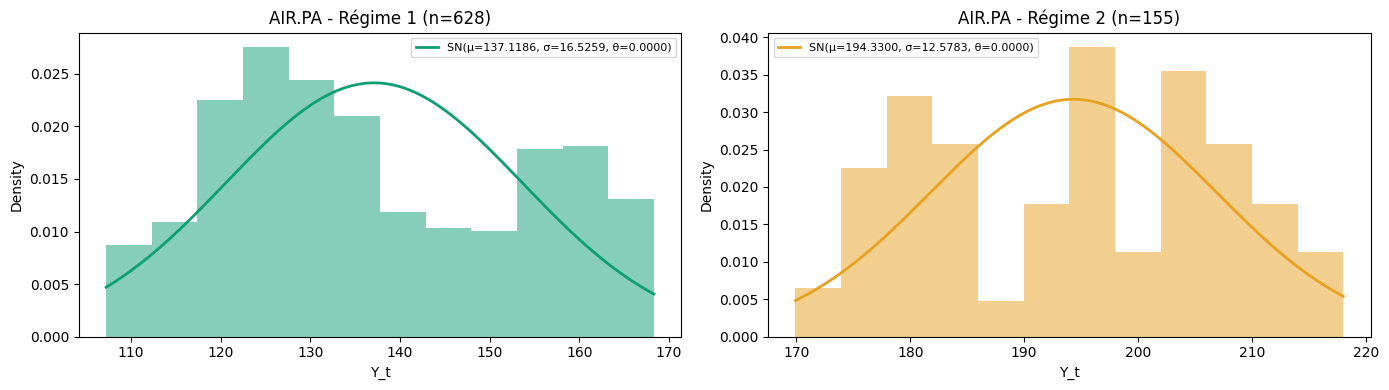

In [14]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, seg, mu, sigma, color, label in [
    (axes[0], y1, mu1_hat, sigma1_hat, '#0E9E74', f'Régime 1 (n={len(y1)})'),
    (axes[1], y2, mu2_hat, sigma2_hat, '#E8A020', f'Régime 2 (n={len(y2)})'),
]:
    x_grid = np.linspace(np.min(seg), np.max(seg), 400)
    ax.hist(seg, bins=12, density=True, alpha=0.5, color=color)
    ax.plot(x_grid, skew_normal_pdf(x_grid, mu, sigma, theta_hat),
            color=color, lw=2,
            label=f'SN(μ={mu:.4f}, σ={sigma:.4f}, θ={theta_hat:.4f})')
    ax.set_title(f'AIR.PA - {label}')
    ax.set_xlabel('Y_t'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation — AIR.PA

In [15]:
interpretation_airpa = (
    f"For AIR.PA, the estimated rupture point is k_hat = {k_hat} "
    f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
    f"p-value is {best_pval:.4f}, so the decision is: {verdict_airpa}. "
    f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
    f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
)
print(interpretation_airpa)

For AIR.PA, the estimated rupture point is k_hat = 628 (2025-06-24). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 137.1186, sigma1 = 16.5259, mu2 = 194.3300, sigma2 = 12.5783, theta = 0.0000.


**Save Result as JSON — AIR.PA**

In [16]:
# SN density curves for Plotly
xg1  = np.linspace(y1.min()-0.004, y1.max()+0.004, 300).tolist()
pdf1 = skew_normal_pdf(np.array(xg1), mu1_hat, sigma1_hat, theta_hat).tolist()
xg2  = np.linspace(y2.min()-0.004, y2.max()+0.004, 300).tolist()
pdf2 = skew_normal_pdf(np.array(xg2), mu2_hat, sigma2_hat, theta_hat).tolist()

airpa_results = {
    "company"       : "AIR.PA",
    "name"          : "Airbus",
    "url"           : "https://fr.finance.yahoo.com/quote/AIR.PA/profile",
    "k_hat"         : int(k_hat),
    "bp_date"       : str(break_date.date()),
    "D"             : round(best_ks, 5),
    "p_value"       : round(best_pval, 6),
    "reject_H0"     : bool(best_pval < 0.05),
    "verdict"       : verdict_airpa,
    "mu1"           : round(mu1_hat, 6),
    "sigma1"        : round(sigma1_hat, 6),
    "mu2"           : round(mu2_hat, 6),
    "sigma2"        : round(sigma2_hat, 6),
    "theta"         : round(theta_hat, 6),
    "n1"            : sn_airpa['n1'],
    "n2"            : sn_airpa['n2'],
    "interpretation": interpretation_airpa,
    "chart_data"    : {
        "dates"   : airpa_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "prices"  : airpa_df["X_t"].tolist(),
        "sm_dates": airpa_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "smoothed": airpa_df["Y_t"].tolist(),
        "Y_dates" : airpa_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "Y"       : Y.tolist(),
        "xg1": xg1, "pdf1": pdf1,
        "xg2": xg2, "pdf2": pdf2,
        "scan_k"  : k_values,
        "scan_D"  : ks_stats,
        "scan_p"  : p_values,

        
    }
}

with open(f"{OUTPUT_DIR}/AIR.PA.json", "w", encoding="utf-8") as f:
    json.dump(airpa_results, f, indent=4, ensure_ascii=False)
print("Saved -> results/json/AIR.PA.json")

Saved -> results/json/AIR.PA.json


---
## AM.PA

### 5. KS Scan over k — AM.PA

In [17]:
Y = ampa_df["Y_t"].to_numpy()
n = len(Y)

k_values, ks_stats, p_values = [], [], []

for k in range(30, n - 29):
    stat, pval = ks_2samp(Y[:k], Y[k:])
    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat      = k_values[best_index]
best_ks    = float(ks_stats[best_index])
best_pval  = float(p_values[best_index])
break_date = ampa_df.loc[k_hat, "Date"]

print("Best rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)

Best rupture point from KS scan
k_hat      = 521
break_date = 2025-01-21
KS stat    = 1.0
p-value    = 1.1827757385384623e-215


**KS Scan Plot and Breakpoint Plot — AM.PA**

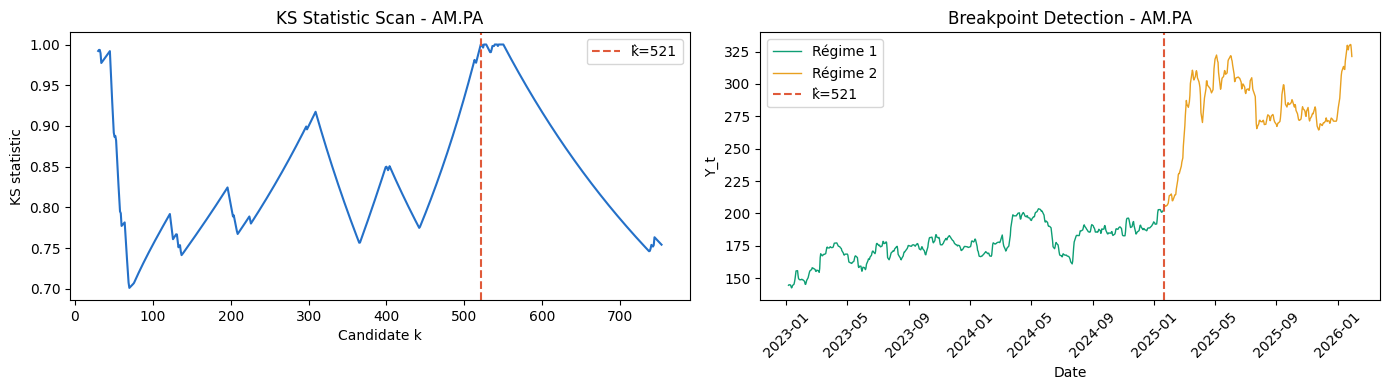

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(k_values, ks_stats, color='#2470C8', lw=1.5)
axes[0].axvline(k_hat, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
axes[0].set_title(f'KS Statistic Scan - AM.PA')
axes[0].set_xlabel('Candidate k'); axes[0].set_ylabel('KS statistic')
axes[0].legend()

axes[1].plot(ampa_df["Date"][:k_hat], Y[:k_hat], color='#0E9E74', lw=1, label='Régime 1')
axes[1].plot(ampa_df["Date"][k_hat:], Y[k_hat:], color='#E8A020', lw=1, label='Régime 2')
axes[1].axvline(break_date, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
axes[1].set_title('Breakpoint Detection - AM.PA')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Y_t')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].legend()
plt.tight_layout(); plt.show()

### 6. Estimate Skew-Normal Parameters — AM.PA

In [19]:
sn_ampa = fit_sn_two_regimes(Y, k_hat)

mu1_hat    = sn_ampa['mu1']
sigma1_hat = sn_ampa['sigma1']
mu2_hat    = sn_ampa['mu2']
sigma2_hat = sn_ampa['sigma2']
theta_hat  = sn_ampa['theta']

print("Joint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", sn_ampa['negll'])

Joint MLE estimates with common theta
mu1    = 177.02536938579655
sigma1 = 13.323479710677802
mu2    = 281.7541084923664
sigma2 = 27.706883646058998
theta  = 0.0
NegLogLik = 3330.4532850706582


In [20]:
verdict_ampa = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"
print("Verdict:", verdict_ampa)

Verdict: Reject H0


**SN Density Fit — AM.PA**

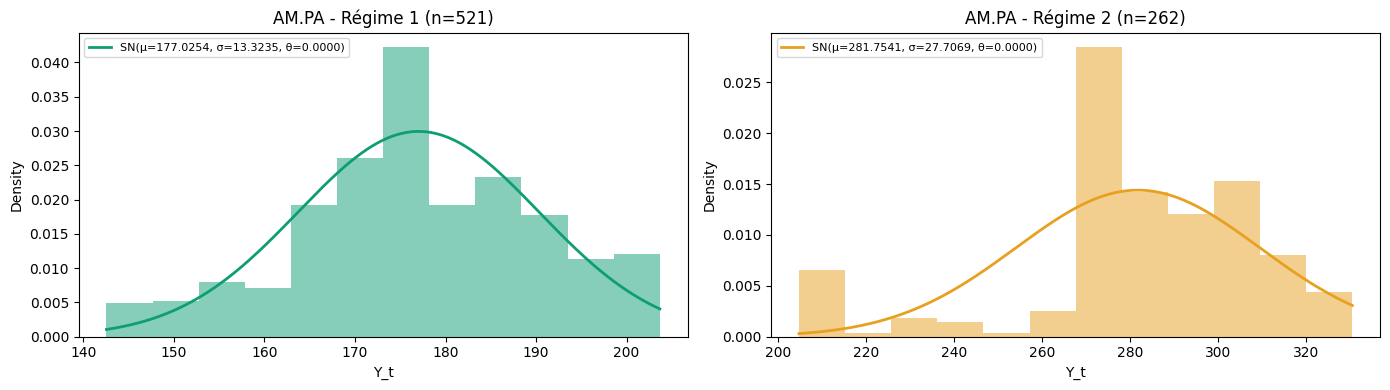

In [21]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, seg, mu, sigma, color, label in [
    (axes[0], y1, mu1_hat, sigma1_hat, '#0E9E74', f'Régime 1 (n={len(y1)})'),
    (axes[1], y2, mu2_hat, sigma2_hat, '#E8A020', f'Régime 2 (n={len(y2)})'),
]:
    x_grid = np.linspace(np.min(seg), np.max(seg), 400)
    ax.hist(seg, bins=12, density=True, alpha=0.5, color=color)
    ax.plot(x_grid, skew_normal_pdf(x_grid, mu, sigma, theta_hat),
            color=color, lw=2,
            label=f'SN(μ={mu:.4f}, σ={sigma:.4f}, θ={theta_hat:.4f})')
    ax.set_title(f'AM.PA - {label}')
    ax.set_xlabel('Y_t'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation — AM.PA

In [22]:
interpretation_ampa = (
    f"For AM.PA, the estimated rupture point is k_hat = {k_hat} "
    f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
    f"p-value is {best_pval:.4f}, so the decision is: {verdict_ampa}. "
    f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
    f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
)
print(interpretation_ampa)

For AM.PA, the estimated rupture point is k_hat = 521 (2025-01-21). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 177.0254, sigma1 = 13.3235, mu2 = 281.7541, sigma2 = 27.7069, theta = 0.0000.


**Save Result as JSON — AM.PA**

In [23]:
xg1  = np.linspace(y1.min()-0.004, y1.max()+0.004, 300).tolist()
pdf1 = skew_normal_pdf(np.array(xg1), mu1_hat, sigma1_hat, theta_hat).tolist()
xg2  = np.linspace(y2.min()-0.004, y2.max()+0.004, 300).tolist()
pdf2 = skew_normal_pdf(np.array(xg2), mu2_hat, sigma2_hat, theta_hat).tolist()

ampa_results = {
    "company"       : "AM.PA",
    "name"          : "Dassault Aviation",
    "url"           : "https://fr.finance.yahoo.com/quote/AM.PA/profile",
    "k_hat"         : int(k_hat),
    "bp_date"       : str(break_date.date()),
    "D"             : round(best_ks, 5),
    "p_value"       : round(best_pval, 6),
    "reject_H0"     : bool(best_pval < 0.05),
    "verdict"       : verdict_ampa,
    "mu1"           : round(mu1_hat, 6),
    "sigma1"        : round(sigma1_hat, 6),
    "mu2"           : round(mu2_hat, 6),
    "sigma2"        : round(sigma2_hat, 6),
    "theta"         : round(theta_hat, 6),
    "n1"            : sn_ampa['n1'],
    "n2"            : sn_ampa['n2'],
    "interpretation": interpretation_ampa,
    "chart_data"    : {
        "dates"   : ampa_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "prices"  : ampa_df["X_t"].tolist(),
        "sm_dates": ampa_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "smoothed": ampa_df["Y_t"].tolist(),
        "Y_dates" : ampa_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "Y"       : Y.tolist(),
        "xg1": xg1, "pdf1": pdf1,
        "xg2": xg2, "pdf2": pdf2,
        "scan_k"  : k_values,
        "scan_D"  : ks_stats,
        "scan_p"  : p_values,
    }
}

with open(f"{OUTPUT_DIR}/AM.PA.json", "w", encoding="utf-8") as f:
    json.dump(ampa_results, f, indent=4, ensure_ascii=False)
print("Saved -> results/json/AM.PA.json")

Saved -> results/json/AM.PA.json
